# Lab 1 — Your own exposure, and a period you can see

**Maths for Post-Quantum Cryptography**, Chapter 1: *What Quantum Computing Actually Breaks*

---

Two short exercises. Neither needs any cryptographic library, and neither needs
quantum hardware — that is rather the point.

**Part A — Mosca arithmetic.** Turn the inequality $x + y > z$ into a chart you
could put in front of a board.

**Part B — See the period.** Do, classically and on a laptop, the exact step
that Shor's algorithm performs quantum-mechanically: find the period of
$a^x \bmod N$ by Fourier transform, then turn that period into a factor of $N$.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else. Install with `pip install numpy matplotlib`, or use the repository
Docker image / devcontainer, where they are pinned.

### How to use this notebook

Run it top to bottom once. Then go back to the sections marked **Your turn**,
which correspond to Exercises 1.6–1.9 in the chapter. Worked solutions are in
Appendix C of the book — try the exercises before you look.

Every section ends with `assert` statements. They are there so that CI can run
this notebook on every commit and catch it if a library change breaks something
underneath you. If an assertion fires on your machine, that is a bug in the lab,
not in your understanding — please open an issue.

In [1]:
from __future__ import annotations

import math
from math import gcd, pi, log2
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

# The printed book is black and white, so the repository figures are too. This
# keeps what you see here consistent with what you see on the page, and it means
# any figure you lift out of the notebook is already print-safe.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — Mosca arithmetic

Michele Mosca's inequality, from §1.5:

> Let $x$ be the number of years your data must remain confidential, $y$ the
> number of years your organisation needs to migrate, and $z$ the number of
> years until a cryptographically relevant quantum computer exists.
> **If $x + y > z$, you are already exposed.**

The quantity worth computing is not whether you are exposed — almost everyone
is — but *by how much*. If migration finishes at $t_0 + y$ and your data must
stay secret until $t_0 + y + x$, then any of that window falling after $z$ is
protected by cryptography that will, by assumption, be broken. The ciphertext
is being recorded now, so that window is lost today.

In [2]:
def exposure(x: float, y: float, z: float, now: float = 2026.0) -> float:
    """Years of data already lost under Mosca's inequality.

    Parameters
    ----------
    x    : years the data must remain confidential (counted from the moment
           migration completes)
    y    : years the organisation needs to complete its migration
    z    : year in which a cryptographically relevant quantum computer arrives
    now  : the year you are doing this arithmetic in

    Returns
    -------
    The number of years of the confidentiality window that fall after `z`,
    and are therefore already exposed. Zero means you finish in time.
    """
    protection_ends = now + y + x     # last year the data must stay secret
    return max(0.0, protection_ends - z)


# Sanity: the inequality in the book is exactly the statement exposure > 0.
assert exposure(x=10, y=6, z=2050) == 0.0          # comfortable
assert exposure(x=10, y=6, z=2035) == 7.0          # 2026+6+10 = 2042, minus 2035
assert exposure(x=25, y=5, z=2035) == 21.0         # long-lived secrets, badly exposed
print("exposure(x=10, y=6, z=2035) =", exposure(10, 6, 2035), "years already lost")

exposure(x=10, y=6, z=2035) = 7.0 years already lost


### The chart

The chart the chapter asks for is the one that shows *why* the answer does not
depend on knowing $z$ precisely. Plot the exposed interval for three plausible
arrival years and the point makes itself.

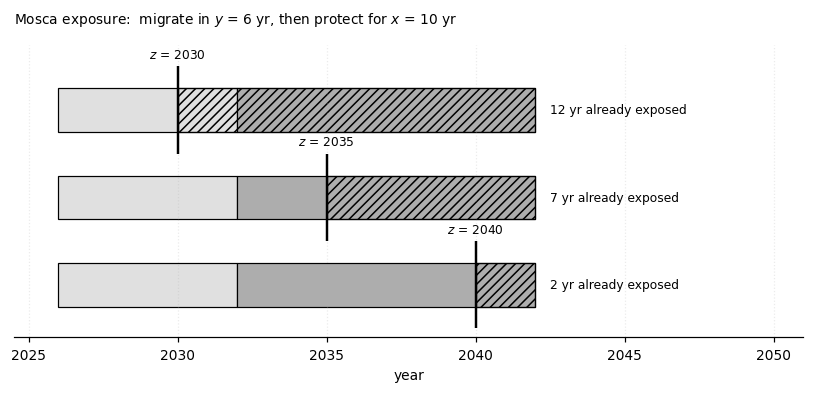

In [3]:
def plot_exposure_bars(x: float, y: float, zs, now: float = 2026.0, ax=None):
    """One lane per candidate arrival year z.

    Each lane shows the migration window, the confidentiality window that
    follows it, and -- hatched -- the part of that window lying after z, which
    is already lost because the ciphertext is being recorded today.
    """
    zs = list(zs)
    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 1.1 + 0.85 * len(zs)))
    end = now + y + x
    H = 0.5

    for i, z in enumerate(zs):
        row = len(zs) - 1 - i
        ax.barh(row, y, left=now, height=H,
                color="0.88", edgecolor="black", linewidth=0.8)
        ax.barh(row, x, left=now + y, height=H,
                color="0.68", edgecolor="black", linewidth=0.8)

        lost = exposure(x, y, z, now)
        if lost > 0:
            # Hatch from z onward. If z lands inside the migration window the
            # hatch covers part of it too, which is correct: nothing you deploy
            # after the machine exists protects traffic captured before it.
            ax.barh(row, end - max(z, now), left=max(z, now), height=H,
                    color="none", edgecolor="black", linewidth=0.8, hatch="////")

        # The arrival rule belongs to this lane only.
        ax.vlines(z, row - H, row + H, color="black", linewidth=1.6)
        ax.text(z, row + H + 0.06, f"$z$ = {int(z)}",
                fontsize=8, ha="center", va="bottom")
        ax.text(end + 0.5, row,
                "safe" if lost == 0 else f"{lost:.0f} yr already exposed",
                fontsize=8, va="center")

    ax.set_yticks([]); ax.set_ylim(-0.6, len(zs) - 0.25)
    ax.spines["left"].set_visible(False)      # no y scale, so no y spine
    ax.set_xlabel("year")
    ax.set_xlim(now - 1.5, end + 9)
    ax.grid(axis="y", visible=False)
    ax.set_title(f"Mosca exposure:  migrate in $y$ = {y} yr, then protect for "
                 f"$x$ = {x} yr", fontsize=9, loc="left", pad=14)
    return ax


ax = plot_exposure_bars(x=10, y=6, zs=[2030, 2035, 2040])
plt.tight_layout(); plt.show()

Read the chart, not the number. The light bar is migration, the darker bar is
the confidentiality requirement, and the hatched tail is what is already lost.
Note that the hatching does not vanish when you push $z$ out by five years —
which is the whole argument for acting on a compliance calendar rather than on
a forecast.

**A caution about $y$.** Most organisations badly underestimate it. Cryptography
is embedded in hardware you cannot reflash, in protocols you do not control, in
certificate hierarchies with their own lifetimes, and in vendor products whose
roadmaps are not yours. Five to seven years is a realistic figure for a large
estate, not a pessimistic one.

### Your turn — Exercise 1.6

Produce the exposure chart for $x = 10$, $y = 6$ and $z$ ranging over
2030–2045 in one-year steps, then find the largest $y$ your organisation could
tolerate at $z = 2035$.

The second half is the useful one: it converts "we are exposed" into a
deadline for the migration programme, which is a thing a budget holder can act
on. A short bisection or a linear scan will do it.

In [4]:
# --- Exercise 1.6 --------------------------------------------------------
# (a) exposure as a function of z, for x = 10, y = 6
zs = np.arange(2030, 2046)
# lost = ...            # hint: a list comprehension over zs using exposure()

# (b) largest tolerable y at z = 2035, holding x = 10
# max_y = ...           # hint: the largest y with exposure(10, y, 2035) == 0

# Uncomment to check your answer against the closed form:
# assert abs(max_y - (2035 - 2026 - 10)) < 1e-9

---

## Part B — See the period

Recall §1.3. To factor an odd composite $N$ that is not a prime power, pick $a$
coprime to $N$ and let

$$f(x) = a^x \bmod N.$$

This is periodic with period $r = \operatorname{ord}_N(a)$. If $r$ is even and
$a^{r/2} \not\equiv -1 \pmod N$, then

$$\gcd\!\left(a^{r/2} - 1,\; N\right)$$

is a non-trivial factor of $N$.

**Everything in that paragraph runs on a laptop.** The only thing a quantum
computer contributes is finding $r$ quickly for an $N$ with 2048 bits. For
$N = 15$ we can find it by inspection.

In [5]:
def order(a: int, N: int) -> int:
    """Multiplicative order of a modulo N, by brute force.

    This is the step Shor's algorithm replaces. It is exponential in log N,
    which is exactly why RSA works against classical adversaries.
    """
    if gcd(a, N) != 1:
        raise ValueError(f"{a} is not a unit modulo {N}")
    r, x = 1, a % N
    while x != 1:
        x = (x * a) % N
        r += 1
    return r


assert order(7, 15) == 4
assert order(14, 15) == 2
assert order(2, 21) == 6
print("ord_15(7) =", order(7, 15), " ord_15(14) =", order(14, 15))

ord_15(7) = 4  ord_15(14) = 2


### The picture from Figure 1.1

Plot $a^x \bmod N$ and the period is visible without any mathematics at all.

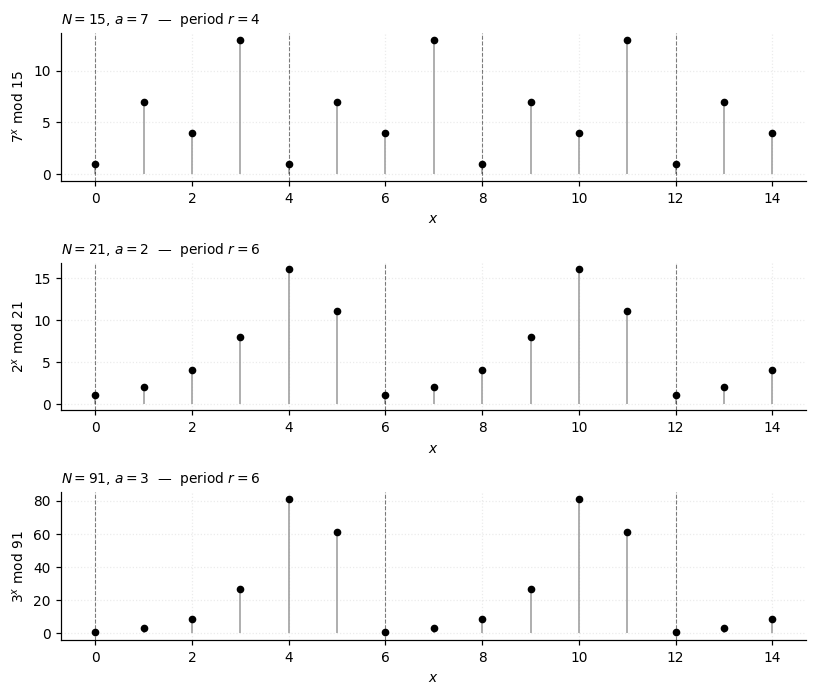

In [6]:
def plot_powers(a: int, N: int, upto: int = 13, ax=None):
    r = order(a, N)
    xs = np.arange(upto)
    ys = np.array([pow(a, int(x), N) for x in xs])
    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 2.4))
    ax.vlines(xs, 0, ys, color="0.6", linewidth=1)
    ax.plot(xs, ys, "o", color="black", markersize=4)
    for k in range(0, upto, r):
        ax.axvline(k, color="black", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.set_xlabel("$x$"); ax.set_ylabel(f"${a}^x \\ \\mathrm{{mod}}\\ {N}$")
    ax.set_title(f"$N = {N}$, $a = {a}$  —  period $r = {r}$",
                 fontsize=9, loc="left")
    return ax


fig, axes = plt.subplots(3, 1, figsize=(7.5, 6.4))
for ax, (a, N) in zip(axes, [(7, 15), (2, 21), (3, 91)]):
    plot_powers(a, N, upto=15, ax=ax)
plt.tight_layout(); plt.show()

### Now find the period the way Shor does — by Fourier transform

Shor's algorithm prepares a superposition over $x$, evaluates $f$ into a second
register, and applies a **quantum** Fourier transform. Because $f$ is periodic,
the amplitudes concentrate on multiples of $M/r$.

We will do exactly the same thing with a **classical** DFT on the sequence
itself. The transform is the same transform; what a quantum computer buys you is
the ability to apply it to a superposition of size $2^{2048}$, which is a
hardware problem and not a mathematical one.

We subtract the mean first, purely so that the DC component at bin 0 does not
dominate the plot.

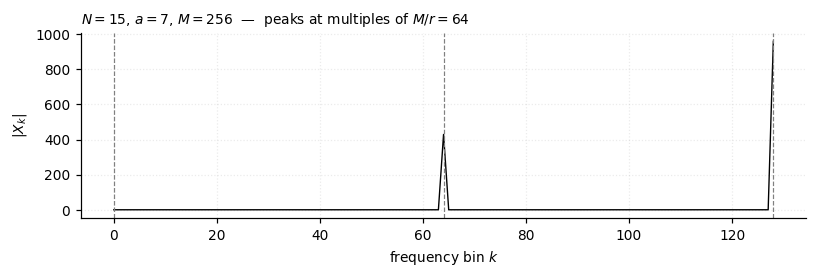

significant bins: [64, 128]


In [7]:
def spectrum(a: int, N: int, M: int = 256):
    """Magnitude spectrum of one period-M window of a^x mod N."""
    seq = np.array([pow(a, int(x), N) for x in range(M)], dtype=float)
    return np.abs(np.fft.rfft(seq - seq.mean()))


def significant_bins(mag, rel=1e-6):
    """Bins carrying real signal, as opposed to floating-point dust."""
    return np.flatnonzero(mag > rel * mag.max())


a, N, M = 7, 15, 256
mag = spectrum(a, N, M)
r = order(a, N)

fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.plot(np.arange(len(mag)), mag, color="black", linewidth=0.9)
for k in range(0, len(mag), M // r):
    ax.axvline(k, color="0.5", linestyle="--", linewidth=0.8)
ax.set_xlabel("frequency bin $k$"); ax.set_ylabel("$|X_k|$")
ax.set_title(f"$N = {N}$, $a = {a}$, $M = {M}$  —  peaks at multiples of "
             f"$M/r = {M // r}$", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

print("significant bins:", significant_bins(mag).tolist())
assert set(significant_bins(mag).tolist()) <= {64, 128}   # multiples of M/r = 64

### The detail that makes Shor's algorithm hard

The spectrum above is *clean* because $M = 256$ is an exact multiple of
$r = 4$. That is a coincidence of the toy example, and it is not available in
the real algorithm: $M$ is a power of two fixed in advance, and $r$ is the
unknown you are trying to find.

Watch what happens when $r \nmid M$.

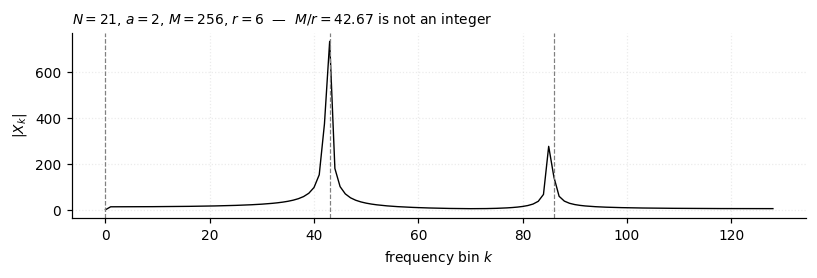

strongest bin: 43;   M/r = 42.667;   peak/M = 0.167969
nearest rational with denominator <= 21: 1/6


In [8]:
a, N, M = 2, 21, 256
r = order(a, N)                     # r = 6, and 6 does not divide 256
mag = spectrum(a, N, M)

fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.plot(np.arange(len(mag)), mag, color="black", linewidth=0.9)
for k in range(0, len(mag), max(1, round(M / r))):
    ax.axvline(k, color="0.5", linestyle="--", linewidth=0.8)
ax.set_xlabel("frequency bin $k$"); ax.set_ylabel("$|X_k|$")
ax.set_title(f"$N = {N}$, $a = {a}$, $M = {M}$, $r = {r}$  —  "
             f"$M/r = {M / r:.2f}$ is not an integer", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

peak = int(np.argmax(mag))
print(f"strongest bin: {peak};   M/r = {M / r:.3f};   peak/M = {peak / M:.6f}")
print(f"nearest rational with denominator <= {N}: "
      f"{Fraction(peak / M).limit_denominator(N)}")

The peaks have smeared, and the strongest bin is no longer an exact multiple of
$M/r$ — it is *close to* $s \cdot M / r$ for some unknown integer $s$. So the
measurement gives you an approximation to $s/r$, and you must recover $r$ from
it.

That is what **continued fractions** are for, and it is why the classical
post-processing of Shor's algorithm is not merely a `gcd`. The cell above uses
`Fraction.limit_denominator`, which is a continued-fraction expansion under a
different name: it returns the best rational approximation with denominator at
most $N$, and its denominator is a candidate for $r$.

This is the single most-skipped detail in popular accounts of Shor's algorithm,
and it is worth understanding, because it is also where the algorithm's success
probability comes from.

In [9]:
def recover_period(a: int, N: int, M: int = 4096) -> int | None:
    """Recover r from the DFT peak, the way Shor's classical post-processing does.

    Returns None if the candidate denominator does not actually verify --
    which is a real outcome of the algorithm, not a bug, and is why Shor's
    algorithm is repeated.
    """
    mag = spectrum(a, N, M)
    peak = int(np.argmax(mag))
    candidate = Fraction(peak, M).limit_denominator(N).denominator
    # Verify before trusting: the quantum algorithm must do this too.
    for mult in range(1, 5):                       # the peak may give r/s, not r
        r = candidate * mult
        if r > 0 and pow(a, r, N) == 1:
            return r
    return None


for a, N in [(7, 15), (2, 21), (3, 91), (5, 91), (10, 91)]:
    got, truth = recover_period(a, N), order(a, N)
    flag = "ok" if got == truth else f"-> got {got}"
    print(f"N = {N:3d}, a = {a:3d}:  true r = {truth:2d}   {flag}")
    assert got == truth, (a, N, got, truth)

N =  15, a =   7:  true r =  4   ok
N =  21, a =   2:  true r =  6   ok
N =  91, a =   3:  true r =  6   ok
N =  91, a =   5:  true r = 12   ok
N =  91, a =  10:  true r =  6   ok


### From the period to a factor

The last step is elementary number theory, and it is the same three lines
whether $N$ has four digits or six hundred.

In [10]:
def factor_from_period(a: int, N: int, r: int):
    """Return a non-trivial factor pair of N, or None if this `a` is useless.

    Fails exactly when r is odd, or when a^(r/2) == -1 (mod N) -- in which case
    a^(r/2) -+ 1 are 0 and -2 modulo N, and both gcds come out trivial.
    """
    if r % 2 != 0:
        return None
    half = pow(a, r // 2, N)
    if half == N - 1:                       # a^(r/2) == -1 (mod N)
        return None
    p, q = gcd(half - 1, N), gcd(half + 1, N)
    if 1 < p < N:
        return (p, N // p)
    if 1 < q < N:
        return (q, N // q)
    return None


for a, N in [(7, 15), (14, 15), (2, 21), (5, 21), (3, 91)]:
    r = order(a, N)
    res = factor_from_period(a, N, r)
    why = "" if res else ("  (r is odd)" if r % 2 else "  (a^(r/2) = -1 mod N)")
    print(f"N = {N:3d}, a = {a:3d}, r = {r:2d}  ->  {res}{why}")

assert factor_from_period(7, 15, order(7, 15)) in [(3, 5), (5, 3)]
assert factor_from_period(14, 15, order(14, 15)) is None   # 14 == -1 (mod 15)
assert factor_from_period(3, 91, order(3, 91)) in [(7, 13), (13, 7)]

N =  15, a =   7, r =  4  ->  (3, 5)
N =  15, a =  14, r =  2  ->  None  (a^(r/2) = -1 mod N)
N =  21, a =   2, r =  6  ->  (7, 3)
N =  21, a =   5, r =  6  ->  None  (a^(r/2) = -1 mod N)
N =  91, a =   3, r =  6  ->  (13, 7)


Note $a = 14$ for $N = 15$. Here $14 \equiv -1 \pmod{15}$, so $r = 2$ and
$a^{r/2} = 14 \equiv -1$. Both gcds collapse: $\gcd(13, 15) = 1$ and
$\gcd(15, 15) = 15$. This is exactly the failure condition in §1.3, and it is
the subject of Exercise 1.1.

### How often does a random $a$ work?

The chapter claims the two conditions hold with probability at least
$1 - 2^{-(m-1)}$, where $m$ is the number of distinct odd prime factors of $N$.
For a semiprime like 15, 21 or 91 that is $m = 2$, so the guarantee is only
$1/2$ — and it is worth checking whether that bound is loose or tight.

In [11]:
def success_rate(N: int) -> tuple[int, int, float]:
    """Exhaustive: fraction of units mod N for which the factoring step works."""
    units = [a for a in range(1, N) if gcd(a, N) == 1]
    good = [a for a in units
            if factor_from_period(a, N, order(a, N)) is not None]
    return len(good), len(units), len(good) / len(units)


def n_distinct_odd_primes(N: int) -> int:
    m, d, n = 0, 3, N
    while n % 2 == 0:
        n //= 2
    while d * d <= n:
        if n % d == 0:
            m += 1
            while n % d == 0:
                n //= d
        d += 2
    return m + (1 if n > 1 else 0)


print(f"{'N':>6} {'m':>2} {'successes':>12} {'rate':>7}   bound 1-2^-(m-1)")
for N in [15, 21, 33, 35, 91, 105, 1155]:
    g, t, rate = success_rate(N)
    m = n_distinct_odd_primes(N)
    bound = 1 - 2.0 ** (-(m - 1))
    print(f"{N:>6} {m:>2} {g:>5}/{t:<6} {rate:>7.4f}   {bound:.4f}"
          f"{'   <-- tight' if abs(rate - bound) < 1e-12 else ''}")
    assert rate >= bound - 1e-12, f"bound violated at N={N}"

     N  m    successes    rate   bound 1-2^-(m-1)
    15  2     6/8       0.7500   0.5000
    21  2     6/12      0.5000   0.5000   <-- tight
    33  2    10/20      0.5000   0.5000   <-- tight
    35  2    18/24      0.7500   0.5000
    91  2    54/72      0.7500   0.5000
   105  3    42/48      0.8750   0.7500
  1155  4   450/480     0.9375   0.8750


Two things to take from that table.

**The bound is tight.** $N = 21$ and $N = 33$ hit exactly $1/2$. So the
guarantee really is only a coin flip for the semiprimes that matter — you
cannot promise better without knowing something about $N$.

**It is also pessimistic in the typical case.** $N = 15$ and $N = 91$ both
manage $3/4$. And because failures are independent across draws, ten random
attempts fail entirely with probability at most $2^{-10}$, which is why "a
handful of attempts suffices" is a fair summary even with a worst case of $1/2$.

If you are tempted to conclude that a $1/2$ success rate makes Shor's algorithm
impractical: it does not, and the reason is worth internalising. A repeated
trial with constant success probability costs a constant factor. A quantum
speedup on a problem with no exploitable structure costs a square root. Neither
of those is what breaks RSA. What breaks RSA is that the abelian hidden-subgroup
structure turns an exponential problem into a polynomial one, and no amount of
retrying changes that exponent.

### Your turn — Exercise 1.7

For $N = 91$, tabulate the order $r$ of every $a$ coprime to 91, compute the
empirical fraction for which the factoring step succeeds, and compare with your
answer to Exercise 1.2.

While you are there, look at the *distribution* of $r$. The orders all divide
$\lambda(91) = \operatorname{lcm}(6, 12) = 12$, and the failures are not spread
evenly across them — see whether you can say which orders produce failures and
why.

In [12]:
# --- Exercise 1.7 --------------------------------------------------------
# rows = [(a, order(a, 91), factor_from_period(a, 91, order(a, 91))) ...]
# Then: how many succeed? Which values of r account for the failures?

---

## Your turn — Exercise 1.8: depth-limited Grover

This one has nothing to do with Parts A and B; it is the computational half of
§1.4, and it is the exercise that will change how you read a security claim.

From Derivation 1.2, a depth-limited Grover attack on a $k$-bit key needs

$$m \;\ge\; \left(\frac{d_1\,2^{k/2}}{D}\right)^{2}$$

parallel machines, where $d_1$ is the depth of one Grover iteration and $D$ is
`MAXDEPTH`. The chapter gives you the *full* attack depth for AES-128 from
Jaques et al. — $1.08 \times 2^{75}$ — but not $d_1$. Derive it by dividing by
the iteration count $\frac{\pi}{4} 2^{64}$.

Then plot $\log_2 m$ against $\log_2 D$ for $D$ from $2^{40}$ to $2^{96}$ and
comment on the slope. The slope is the entire argument of §1.4 in one number —
make sure you can say what it means before you move on.

In [13]:
# --- Exercise 1.8 --------------------------------------------------------
JAQUES_AES128_FULL_DEPTH = 1.08 * 2**75      # Eurocrypt 2020, Table 10 (r = 2)
JAQUES_AES128_GATE_COUNT = 1.34 * 2**83
K = 128

# (a) d_1 = full depth / iteration count
# d1 = ...

# (b) machines required as a function of MAXDEPTH
# def machines(D, k=K, d1=d1): ...
#     (remember: you never need fewer than one machine)

# (c) plot log2(m) against log2(D) for D = 2^40 ... 2^96, and read off the slope.

# (d) Sanity check your work against the chapter: at D = 2^64 the total gate
#     count should come out near NIST's 2^170 / D = 2^106.

### Your turn — Exercise 1.9: the qubit estimates

Compute the ratio of Gidney–Ekerå's 2019 qubit count for RSA-2048 to Gidney's
2025 figure, and the ratio of the two runtimes. Then argue, in under 150 words,
whether the product of those ratios is the right way to compare them.

The figures from §1.3 are below. Before you compute anything, write down what
you expect — and then notice what the product actually is.

In [14]:
# --- Exercise 1.9 --------------------------------------------------------
GIDNEY_EKERA_2019 = {"qubits": 20e6, "hours": 8}
GIDNEY_2025       = {"qubits": 1e6,  "hours": 7 * 24}      # "under a week"

# qubit_ratio = ...
# time_ratio  = ...
# What is qubits x hours in each case? Is that the right cost metric for a
# machine that must hold coherence for the whole run? Is it the right one for a
# funder deciding what to build?

---

## What to take away

The mathematics in Part B is not exotic. You have just factored integers by
Fourier analysis on a laptop, using nothing beyond `numpy.fft`, `gcd` and a
continued-fraction expansion from the standard library.

What is exotic is doing that Fourier transform on a superposition of size
$2^{2048}$. That is a hardware problem — and, as §1.3 notes, the resource
estimates for it fell twenty-fold between 2019 and 2025 without any new physics.

Chapter 2 begins the mathematics of what replaces RSA, starting from $\mathbb{Z}_q$.

---

*Standards status referenced in this lab was verified on 16 August 2026. Live
status: https://mathsforeverything.com/pqc/standards*

In [15]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    assert exposure(10, 6, 2035) == 7.0
    assert exposure(10, 6, 2050) == 0.0
    assert order(7, 15) == 4 and order(2, 21) == 6 and order(3, 91) == 6
    assert set(significant_bins(spectrum(7, 15, 256)).tolist()) <= {64, 128}
    for a, N in [(7, 15), (2, 21), (3, 91), (5, 91), (10, 91)]:
        assert recover_period(a, N) == order(a, N), (a, N)
    assert factor_from_period(7, 15, 4) in [(3, 5), (5, 3)]
    assert factor_from_period(14, 15, 2) is None
    for N in [15, 21, 33, 35, 91, 105, 1155]:
        _, _, rate = success_rate(N)
        assert rate >= 1 - 2.0 ** (-(n_distinct_odd_primes(N) - 1)) - 1e-12
    assert abs(success_rate(21)[2] - 0.5) < 1e-12     # the bound is attained
    assert abs(success_rate(33)[2] - 0.5) < 1e-12
    return "all checks passed"

print(_selftest())

all checks passed
